#### **Importing Libraries**

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from imblearn.over_sampling import SMOTE

#### **Generating the dataset synthetically**

In [3]:

# For reproducibility
np.random.seed(42)
sns.set(style="whitegrid")

# Simulate Data
n = 200
time_spent = np.random.normal(20, 5, n)            # in minutes
coffee_cost = np.random.normal(3.5, 0.5, n)         # in dollars
age = np.random.normal(30, 10, n)                   # in years

# Simulate target: 1 = bought muffin, 0 = did not buy
# Create a probability using a logistic function
prob_muffin = 1 / (1 + np.exp(-(-5 + 0.1*time_spent + 0.8*coffee_cost - 0.03*age)))
bought_muffin = np.random.binomial(1, prob_muffin)

# Create DataFrame
df = pd.DataFrame({
    'Time_Spent': time_spent,
    'Coffee_Cost': coffee_cost,
    'Age': age,
    'Bought_Muffin': bought_muffin
})

print(df.head())


   Time_Spent  Coffee_Cost        Age  Bought_Muffin
0   22.483571     3.678894  14.055723              0
1   19.308678     3.780392  24.006250              1
2   23.238443     4.041526  30.052437              1
3   27.615149     4.026901  30.469806              0
4   18.829233     2.811165  25.499345              0


In [10]:
df['Bought_Muffin'].value_counts()

Bought_Muffin
0    151
1     49
Name: count, dtype: int64

#### Assumption 1: that target variable is binary is met here

In [11]:
df.duplicated().sum()

np.int64(0)

#### Assumption 2 that Each observation is independent  is also met here

In [14]:
# Add constant term to predictors
X = add_constant(df[['Time_Spent', 'Coffee_Cost', 'Age']])

# Calculate VIF
vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)

       Feature        VIF
0        const  79.275234
1   Time_Spent   1.026964
2  Coffee_Cost   1.009545
3          Age   1.018752


#### since ViF for the features is less then 5 so no multicollinearity between them.. hence Assumption 3- no multicollinearity,is also met 

#### OUTLIERS

In [16]:
from scipy.stats import zscore

# Compute Z-scores
z_scores = np.abs(zscore(df[['Time_Spent', 'Coffee_Cost', 'Age']]))
outliers = (z_scores > 3).any(axis=1)

# Print number of outliers and example rows
print(f"Number of outliers: {outliers.sum()}")
print(df[outliers])

Number of outliers: 3
    Time_Spent  Coffee_Cost        Age  Bought_Muffin     logit
9    22.712800     5.426366  35.144388              0  1.140358
62   14.468325     1.879366  23.002745              0 -3.584867
78   20.458804     3.534901  60.788808              0 -2.289543


#### **Checking for Assumption- Linearity of predictors with logodds**

Optimization terminated successfully.
         Current function value: 0.505427
         Iterations 6


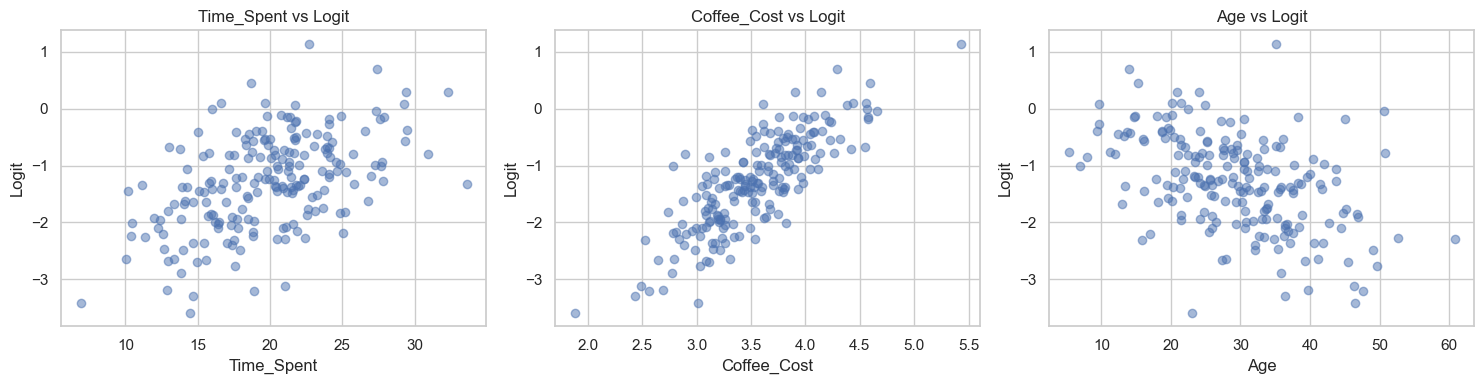

In [15]:
# Fit logistic regression model
X = df[['Time_Spent', 'Coffee_Cost', 'Age']]
X = sm.add_constant(X)
y = df['Bought_Muffin']
model = sm.Logit(y, X).fit()

# Get predicted probabilities
df['logit'] = model.predict(X)
df['logit'] = np.log(df['logit'] / (1 - df['logit']))  # Convert prob to logit

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['Time_Spent', 'Coffee_Cost', 'Age']):
    axes[i].scatter(df[col], df['logit'], alpha=0.5)
    axes[i].set_title(f'{col} vs Logit')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Logit')

plt.tight_layout()
plt.show()


#### scatter plots of predictor vs logit is used to verify, plots roughly shows linearity, hence the assumption is met here 

#### **Train-Test Split and Model Training**

In [4]:
# Define features and target
X = df[['Time_Spent', 'Coffee_Cost', 'Age']]
y = df['Bought_Muffin']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predictions
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]  # for ROC

#### Metrics- Confusion Matrix

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.97      0.85        29
           1       0.67      0.18      0.29        11

    accuracy                           0.75        40
   macro avg       0.71      0.57      0.57        40
weighted avg       0.73      0.75      0.69        40



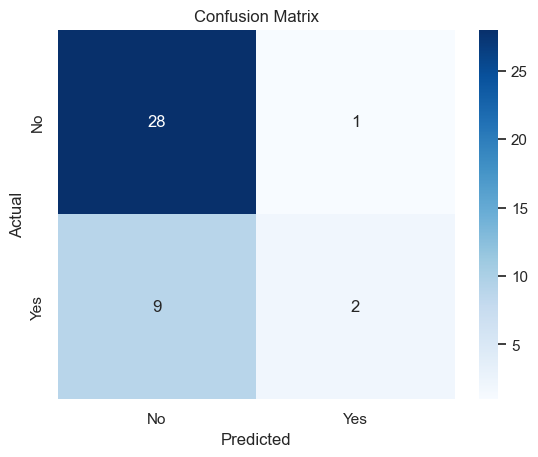

In [20]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### **INTERPRETATION**
##### 1. Out of 40, only 11 bought muffins, so model should be biased towards class 0- 'no muffin'
##### 2. Precision- When model says that bought a muffin, it is only 67% correct
##### 3. Recall- Out of all the actual buyers, only 18% are caught by the model, very low
##### 4. F1 - for class 1, 0.29 is very low, it means model is not able to catch most buyers
##### 5. Accuracy- overall is 75% - not bad, but as per above interpreattion , very misleading, as it will score well when have to detect 'no muffin' but for 'yes' it is misleading


#### **ROC**

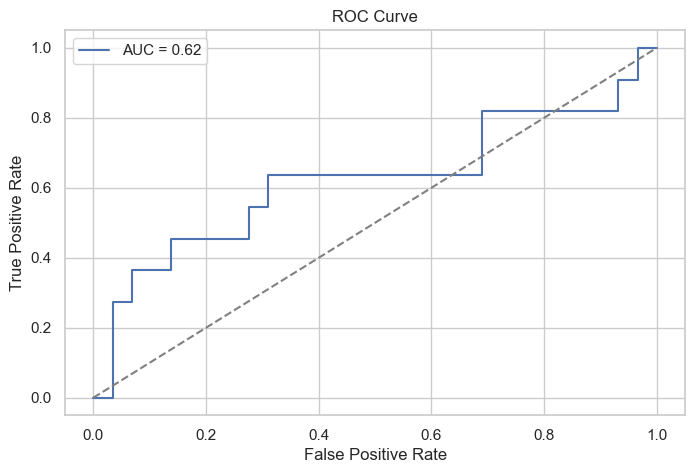

In [21]:

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)


plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Class balancing 

In [22]:
# Train logistic regression with class_weight balanced
model_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)
model_balanced.fit(X_train, y_train)

# Predict on test set
y_pred_balanced = model_balanced.predict(X_test)

# Classification report
print("Classification Report with Balanced Class Weights:")
print(classification_report(y_test, y_pred_balanced))

# Optional: Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_balanced)
print("\nConfusion Matrix:")
print(conf_matrix)

Classification Report with Balanced Class Weights:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        29
           1       0.45      0.45      0.45        11

    accuracy                           0.70        40
   macro avg       0.62      0.62      0.62        40
weighted avg       0.70      0.70      0.70        40


Confusion Matrix:
[[23  6]
 [ 6  5]]


#### INTERPRETATION
##### 1. out of 11 buyers it now predict 5, initially doing 2 only
##### 2. Recall improved from 0.18 to 0.45
##### 3. Accuracy dropped, but initially it was misleading, now sounds bit realistic  but still room for improvement

#### **SMOTE** - Synthetic Minority oversampling Technique- handle class imbalance
##### generate synthetic examples of minority class


In [26]:
# Prepare your features (X) and target (y)
X = df[['Time_Spent', 'Coffee_Cost', 'Age']]
y = df['Bought_Muffin']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to balance the class distribution in the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Initialize Logistic Regression model
model_smote = LogisticRegression()

# Train the model on the resampled training data
model_smote.fit(X_train_res, y_train_res)

# Predict on the test data
y_pred_smote = model_smote.predict(X_test)

# Evaluate the model performance
print("Classification Report with SMOTE:")
print(classification_report(y_test, y_pred_smote))

# Confusion Matrix
print("Confusion Matrix with SMOTE:")
print(confusion_matrix(y_test, y_pred_smote))

Classification Report with SMOTE:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        29
           1       0.45      0.45      0.45        11

    accuracy                           0.70        40
   macro avg       0.62      0.62      0.62        40
weighted avg       0.70      0.70      0.70        40

Confusion Matrix with SMOTE:
[[23  6]
 [ 6  5]]


#### Interpretation
##### 1. SMOTE helped balance the dataset by generating synthetic samples for the minority class (buyers), but the model's ability to predict buyers accurately (class 1) is still limited.
##### 2. The model is better at predicting non-buyers (class 0), as seen by the higher precision and recall values for that class.